In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)

Le chargement a nécessité le package : SeuratObject

Le chargement a nécessité le package : sp


Attachement du package : ‘SeuratObject’


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, t



Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
options(repr.plot.width = 24, repr.plot.height = 17, repr.plot.pointsize = 24)

In [4]:
cluster_color <- c("0" = "#fdf498", "1" = "#807dba", "2" = "#4a1486", "3" = "#ac8fff")

In [5]:
Condition <- c("SE" = "#ff9300", "CTRL" = "#7a81ff")
Time <- c("5" = "#feedde", "10" = "#fdbe85", "20" = "#fd8d3c", "40" = "#d94701")

In [6]:
load("/work/project/fragencode/workspace/umr_1141/results/epilepsie/spatial/seurat_obj/whole_clustering_subclustering_Seurat_objects.RData")

In [7]:
seurat_object_whole_clustering <- seurat_object_subclustering_list$`3`

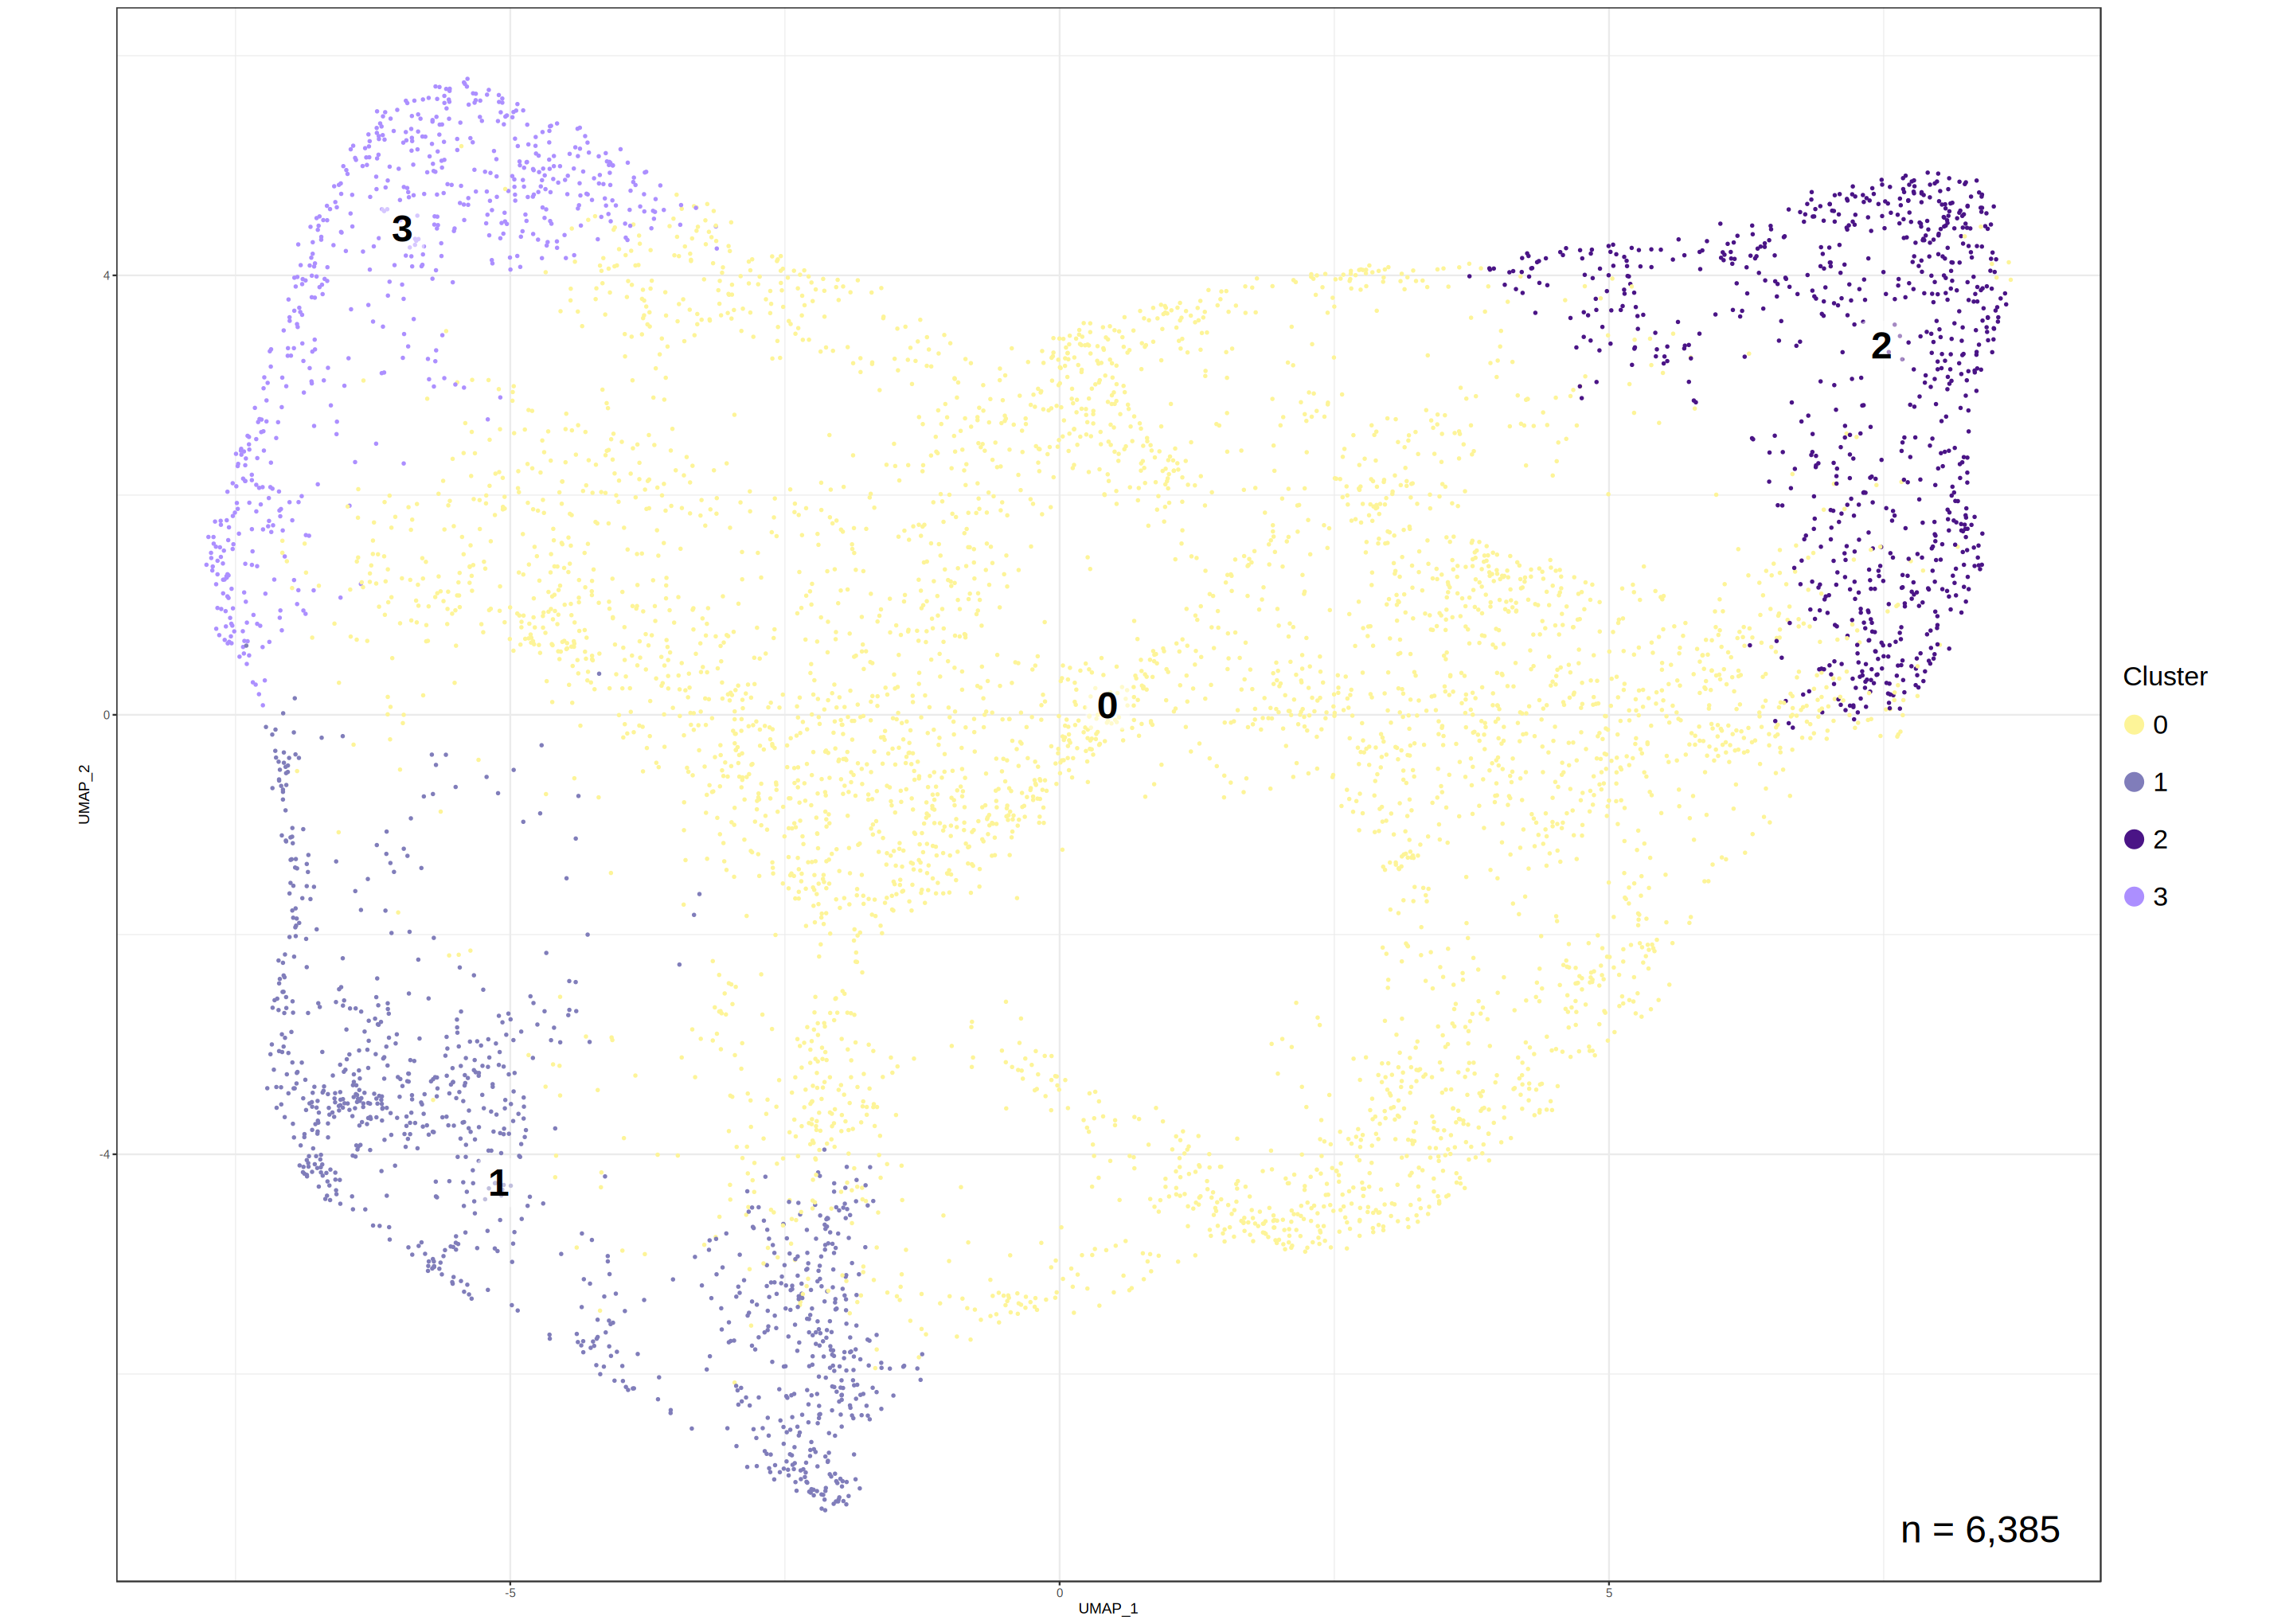

In [ ]:
UMAP_centers_cell_type <- tibble(
    UMAP_1 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_1,
    UMAP_2 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_2,
    seurat_clusters = seurat_object_whole_clustering@meta.data$seurat_clusters
  ) %>%
  group_by(seurat_clusters) %>%
  summarize(x = median(UMAP_1), y = median(UMAP_2))

plot_umap_cluster <- bind_cols(seurat_object_whole_clustering@meta.data, as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)) %>%
  ggplot(aes(UMAP_1, UMAP_2, color = seurat_clusters)) +
  geom_point(size = .5) +
  geom_label(
    data = UMAP_centers_cell_type,
    mapping = aes(x, y, label = seurat_clusters),
    size = 10,
    fill = 'white',
    color = 'black',
    fontface = 'bold',
    alpha = 0.5,
    label.size = 0,
    show.legend = FALSE
  ) +
  theme_bw() +
  scale_color_manual(values = cluster_color) +
  labs(color = 'Cluster') +
  guides(colour = guide_legend(override.aes = list(size = 6))) +
  theme(
      legend.position = 'right',
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 20),
      legend.key.height = unit(3,"line")
  ) +
  coord_fixed() +
  annotate(
    geom = 'text', 
    x = Inf, 
    y = -Inf,
    label = paste0('n = ', format(nrow(seurat_object_whole_clustering@meta.data), big.mark = ',', trim = TRUE)),
    vjust = -1.5,
    hjust = 1.25,
    color = 'black',
    size = 10
  )

plot_umap_cluster

In [10]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cluster_3_UMAP_by_cell_type.svg',
  plot_umap_cluster,
  height = 18,
  width = 20
)

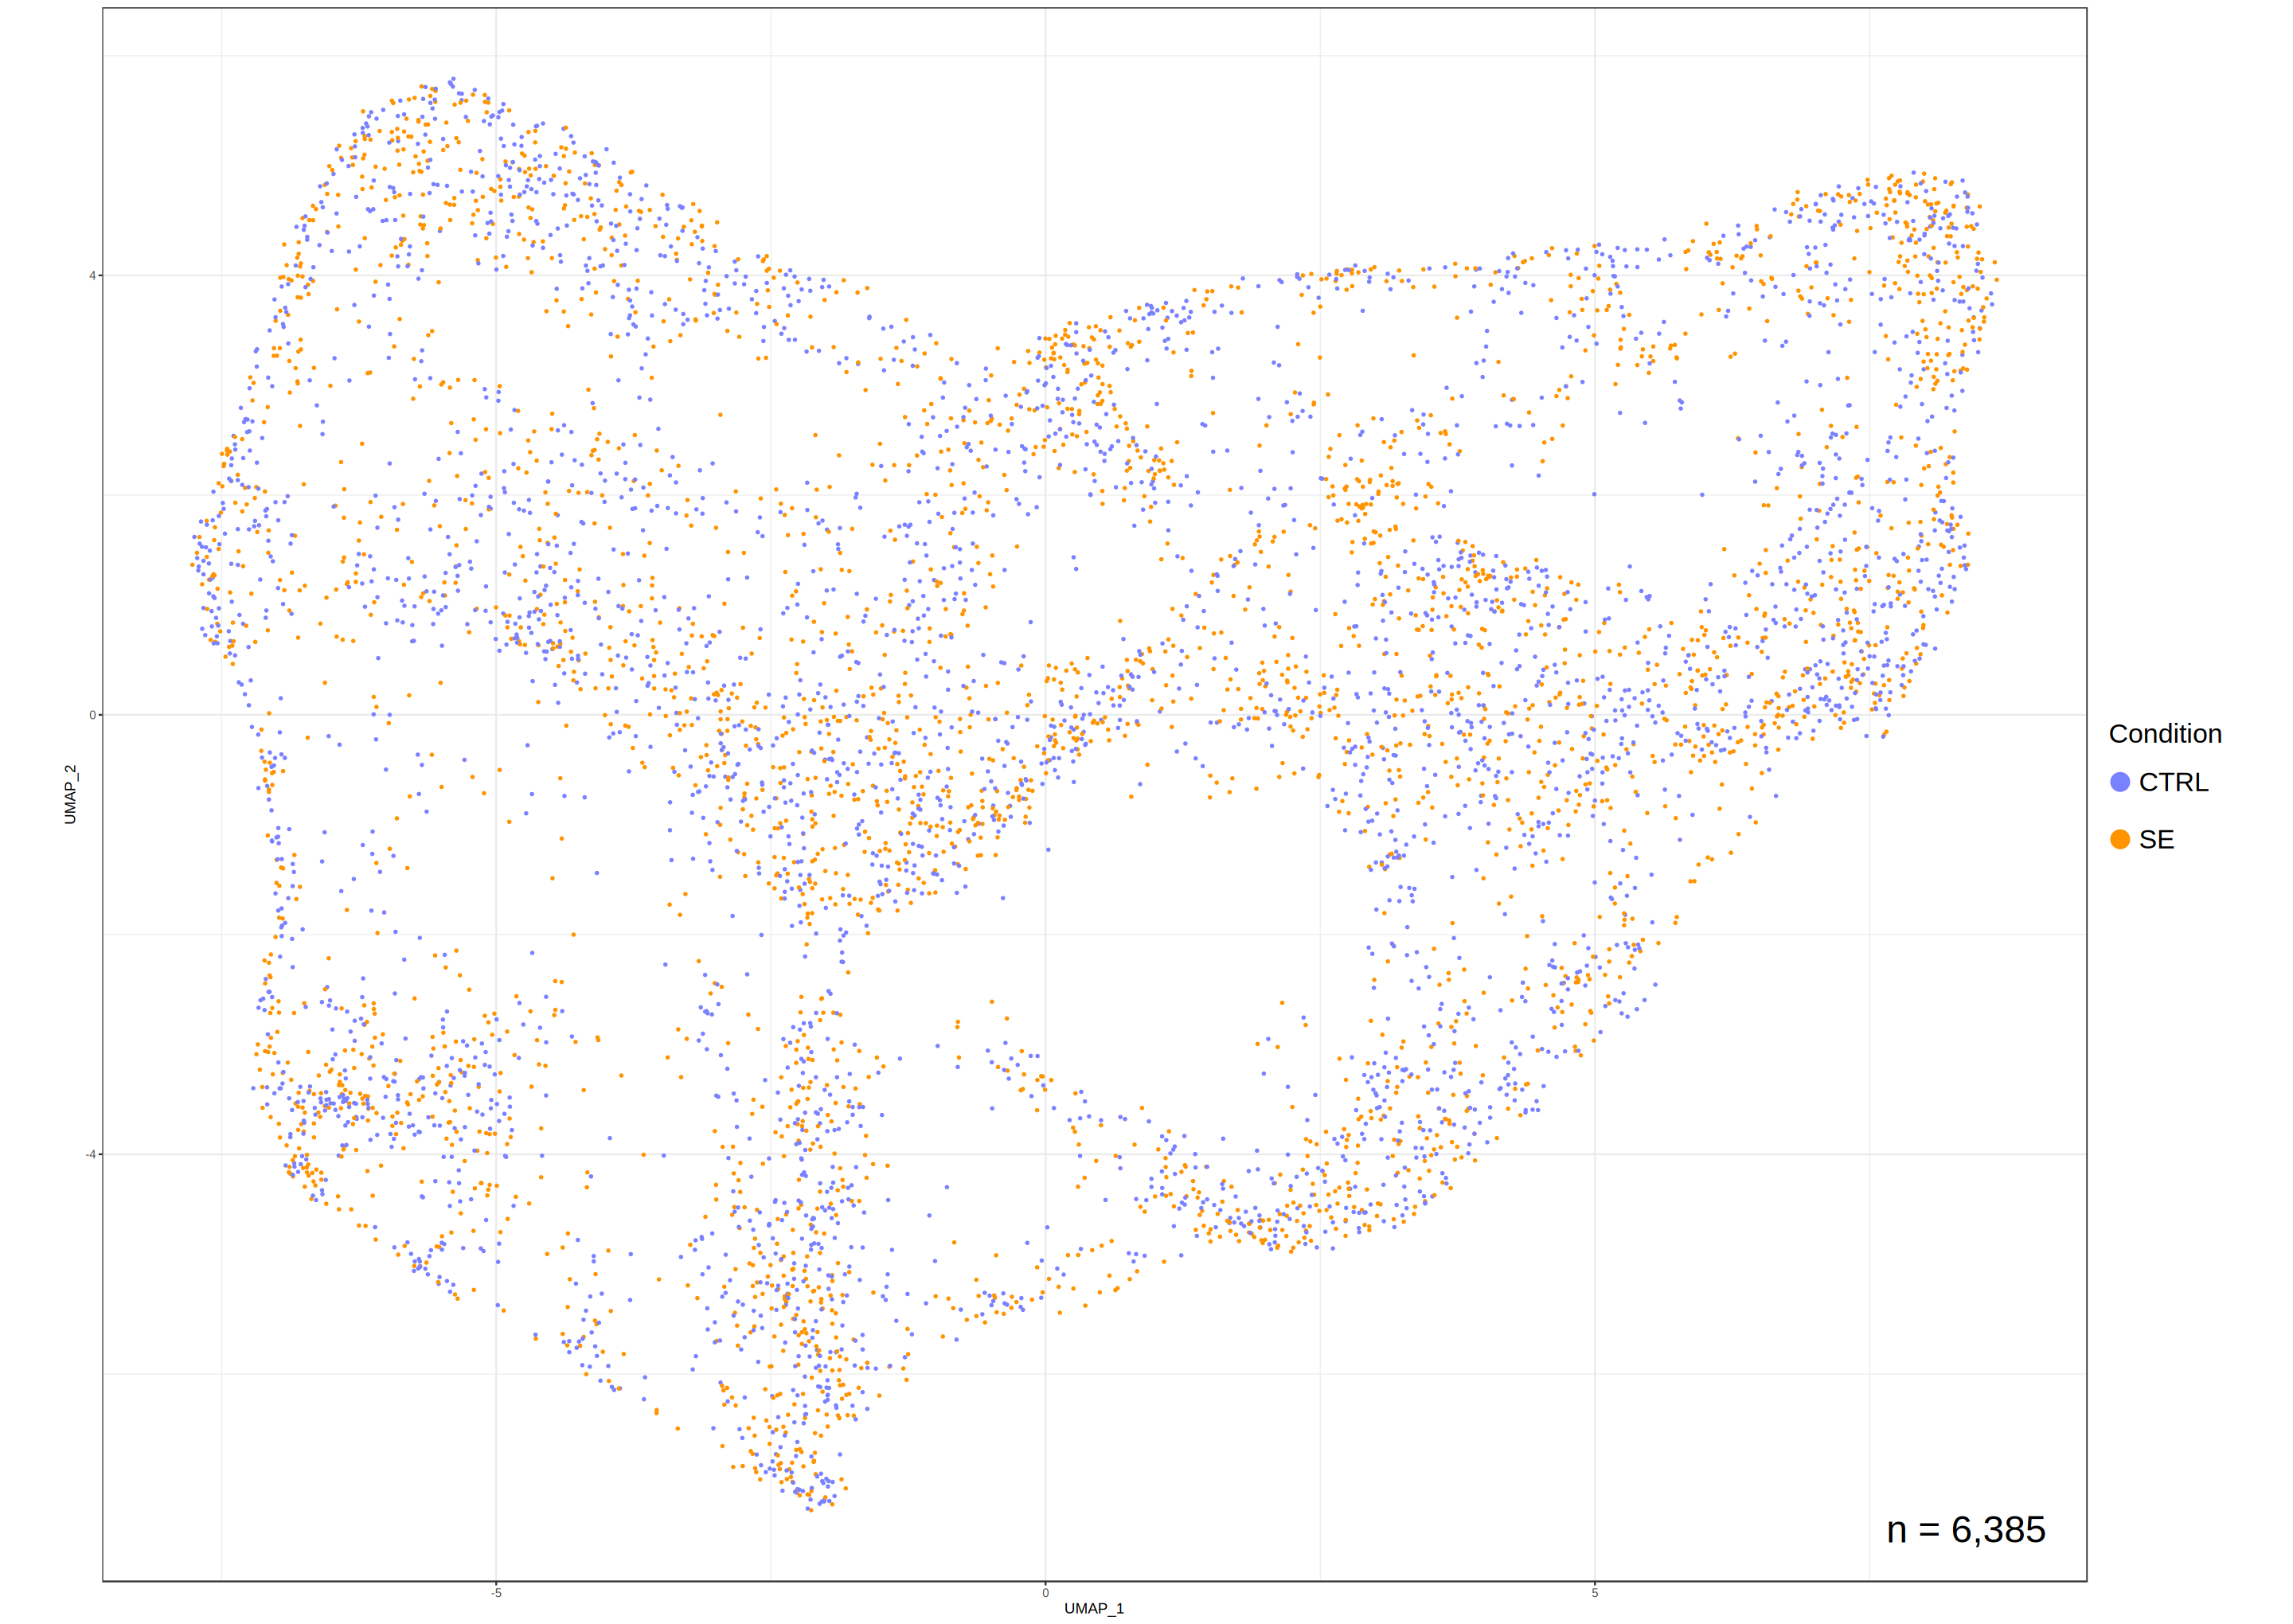

In [ ]:
UMAP_centers_cell_type <- tibble(
    UMAP_1 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_1,
    UMAP_2 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_2,
    seurat_clusters = seurat_object_whole_clustering@meta.data$condition
  ) %>%
  group_by(seurat_clusters) %>%
  summarize(x = median(UMAP_1), y = median(UMAP_2))

plot_umap_cluster <- bind_cols(seurat_object_whole_clustering@meta.data, as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)) %>%
  ggplot(aes(UMAP_1, UMAP_2, color = condition)) +
  geom_point(size = .5) +
  theme_bw() +
  scale_color_manual(values = Condition) +
  labs(color = 'Condition') +
  guides(colour = guide_legend(override.aes = list(size = 6))) +
  theme(
      legend.position = 'right',
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 20),
      legend.key.height = unit(3,"line")
  ) +
  coord_fixed() +
  annotate(
    geom = 'text', 
    x = Inf, 
    y = -Inf,
    label = paste0('n = ', format(nrow(seurat_object_whole_clustering@meta.data), big.mark = ',', trim = TRUE)),
    vjust = -1.5,
    hjust = 1.25,
    color = 'black',
    size = 10
  )

plot_umap_cluster

In [13]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cluster_3_UMAP_by_condition.svg',
  plot_umap_cluster,
  height = 18,
  width = 20
)

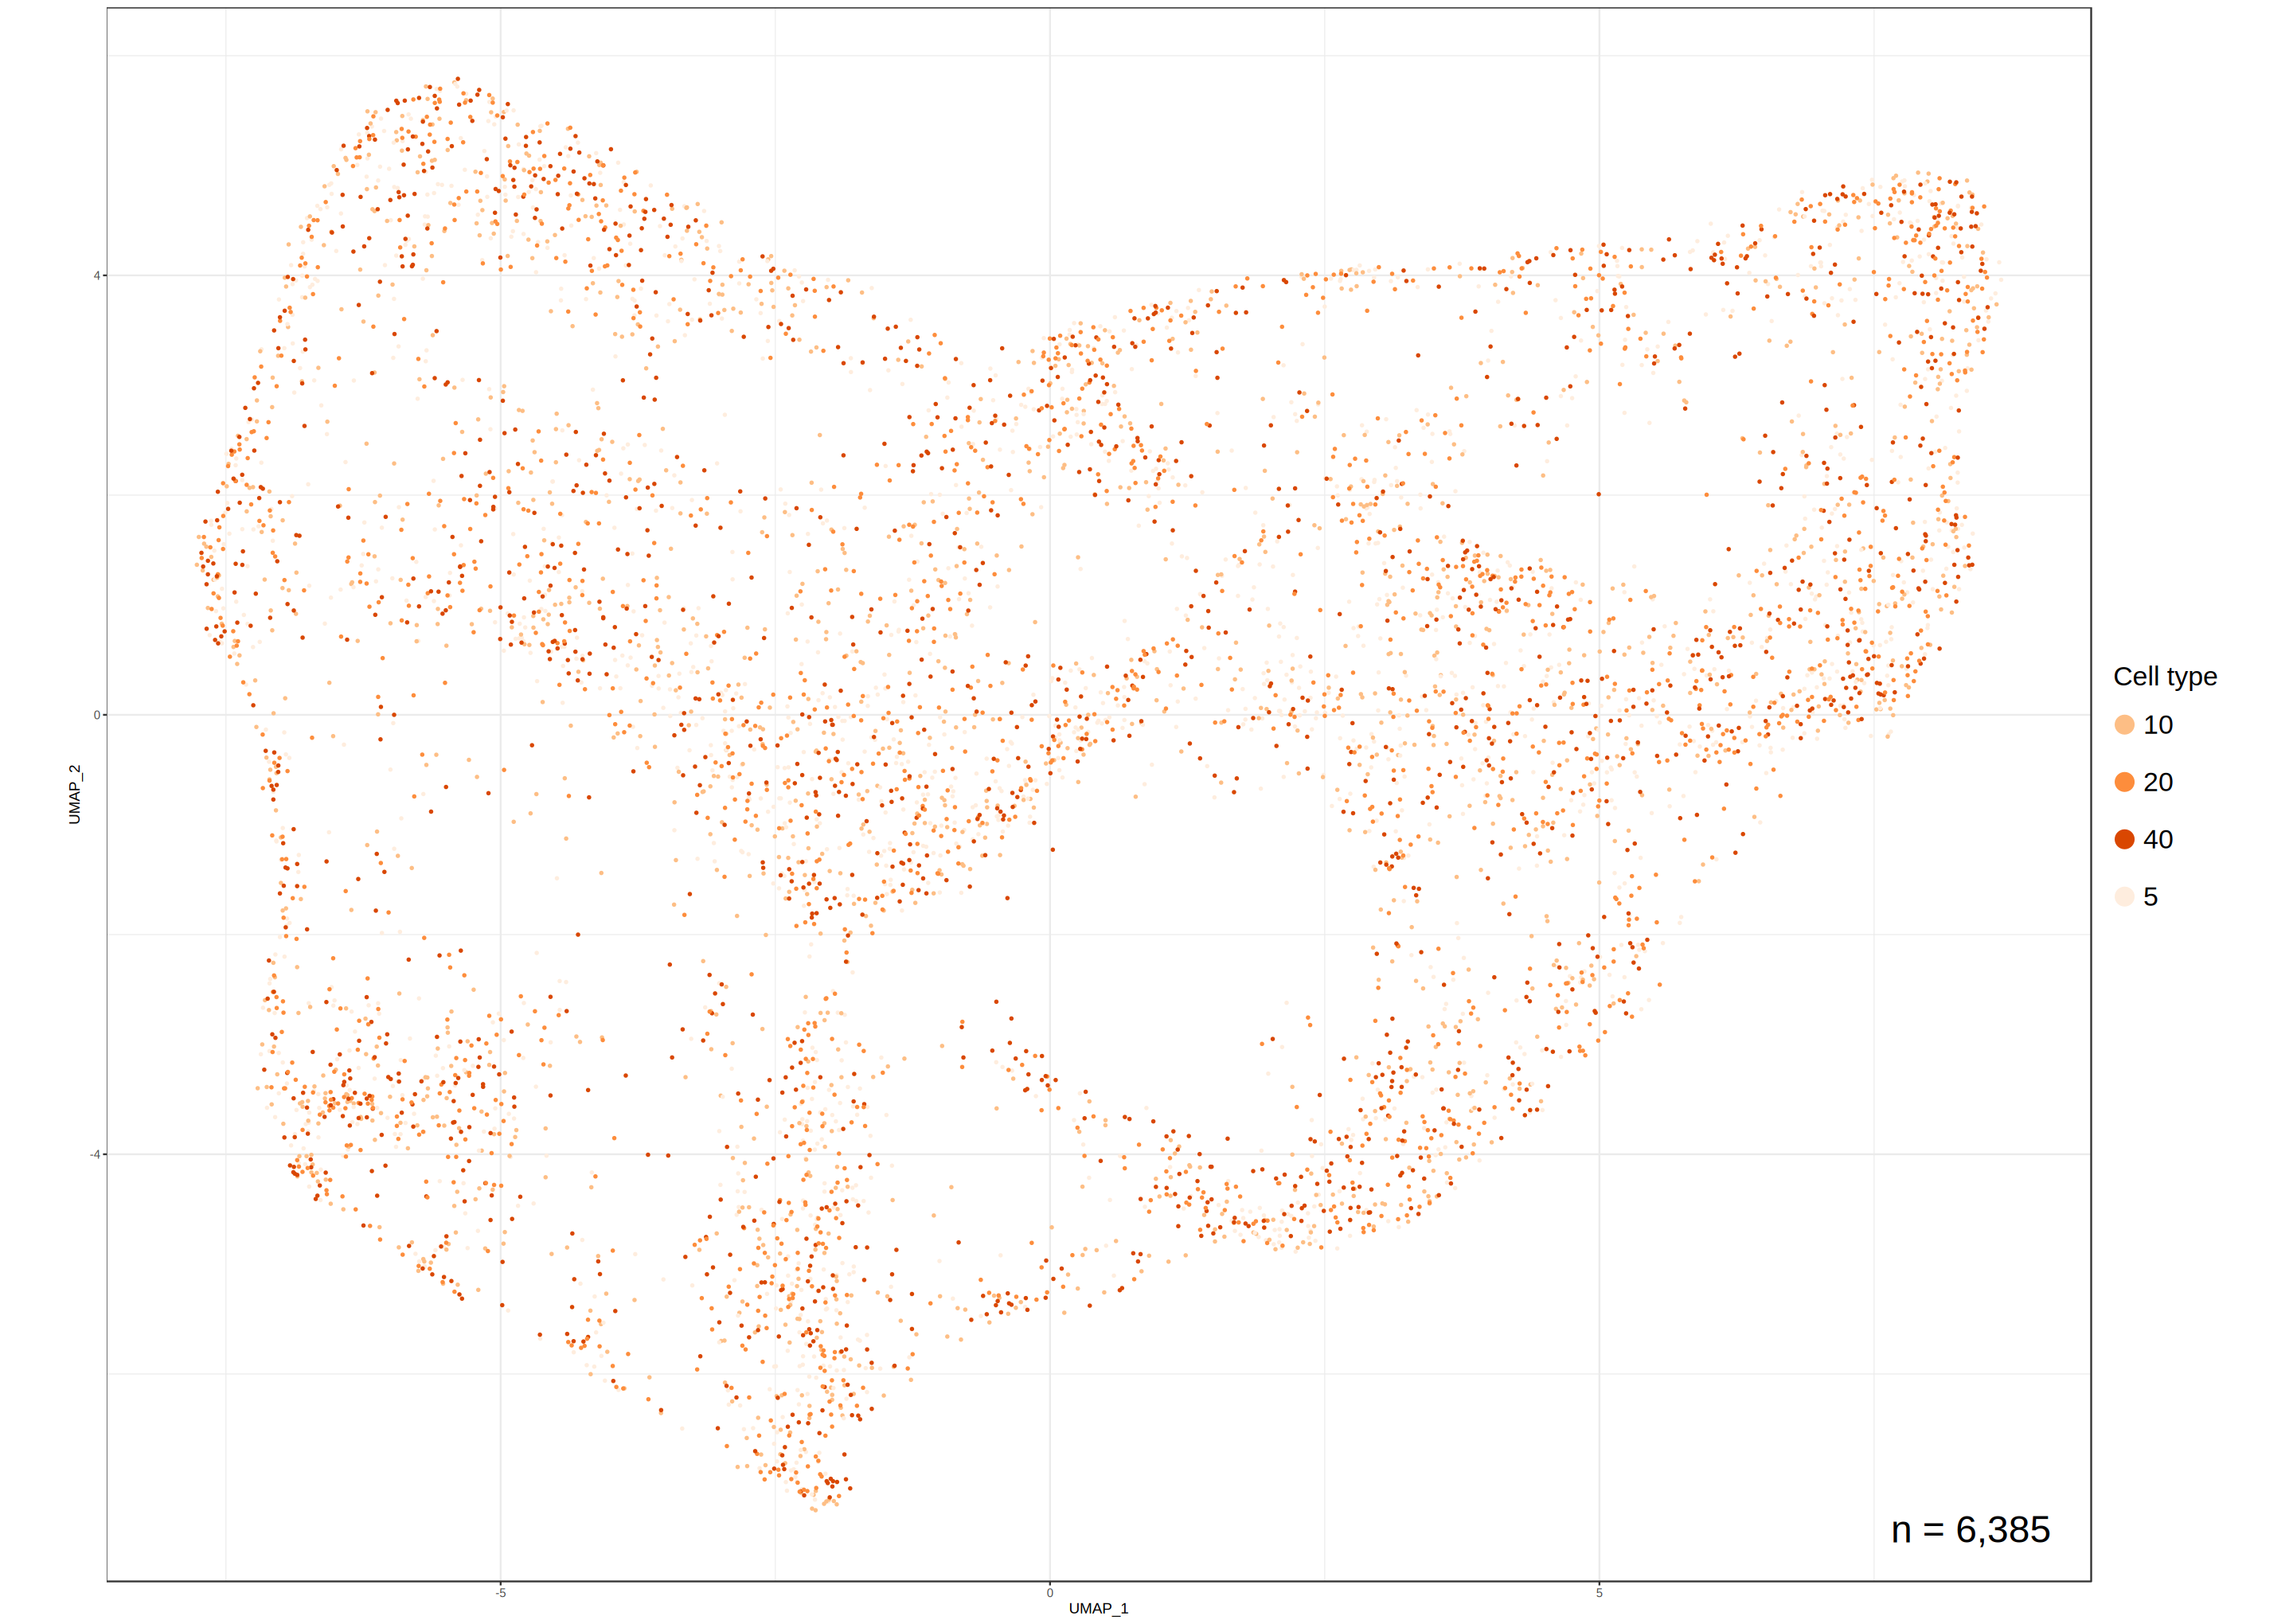

In [ ]:
UMAP_centers_cell_type <- tibble(
    UMAP_1 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_1,
    UMAP_2 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_2,
    seurat_clusters = seurat_object_whole_clustering@meta.data$time
  ) %>%
  group_by(seurat_clusters) %>%
  summarize(x = median(UMAP_1), y = median(UMAP_2))

plot_umap_cluster <- bind_cols(seurat_object_whole_clustering@meta.data, as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)) %>%
  ggplot(aes(UMAP_1, UMAP_2, color = time)) +
  geom_point(size = .5) +
  theme_bw() +
  scale_color_manual(values = Time) +
  labs(color = 'Cell type') +
  guides(colour = guide_legend(override.aes = list(size = 6))) +
  theme(
      legend.position = 'right',
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 20),
      legend.key.height = unit(3,"line")
  ) +
  coord_fixed() +
  annotate(
    geom = 'text', 
    x = Inf, 
    y = -Inf,
    label = paste0('n = ', format(nrow(seurat_object_whole_clustering@meta.data), big.mark = ',', trim = TRUE)),
    vjust = -1.5,
    hjust = 1.25,
    color = 'black',
    size = 10
  )

plot_umap_cluster

In [15]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cluster_3_UMAP_by_time.svg',
  plot_umap_cluster,
  height = 18,
  width = 20
)

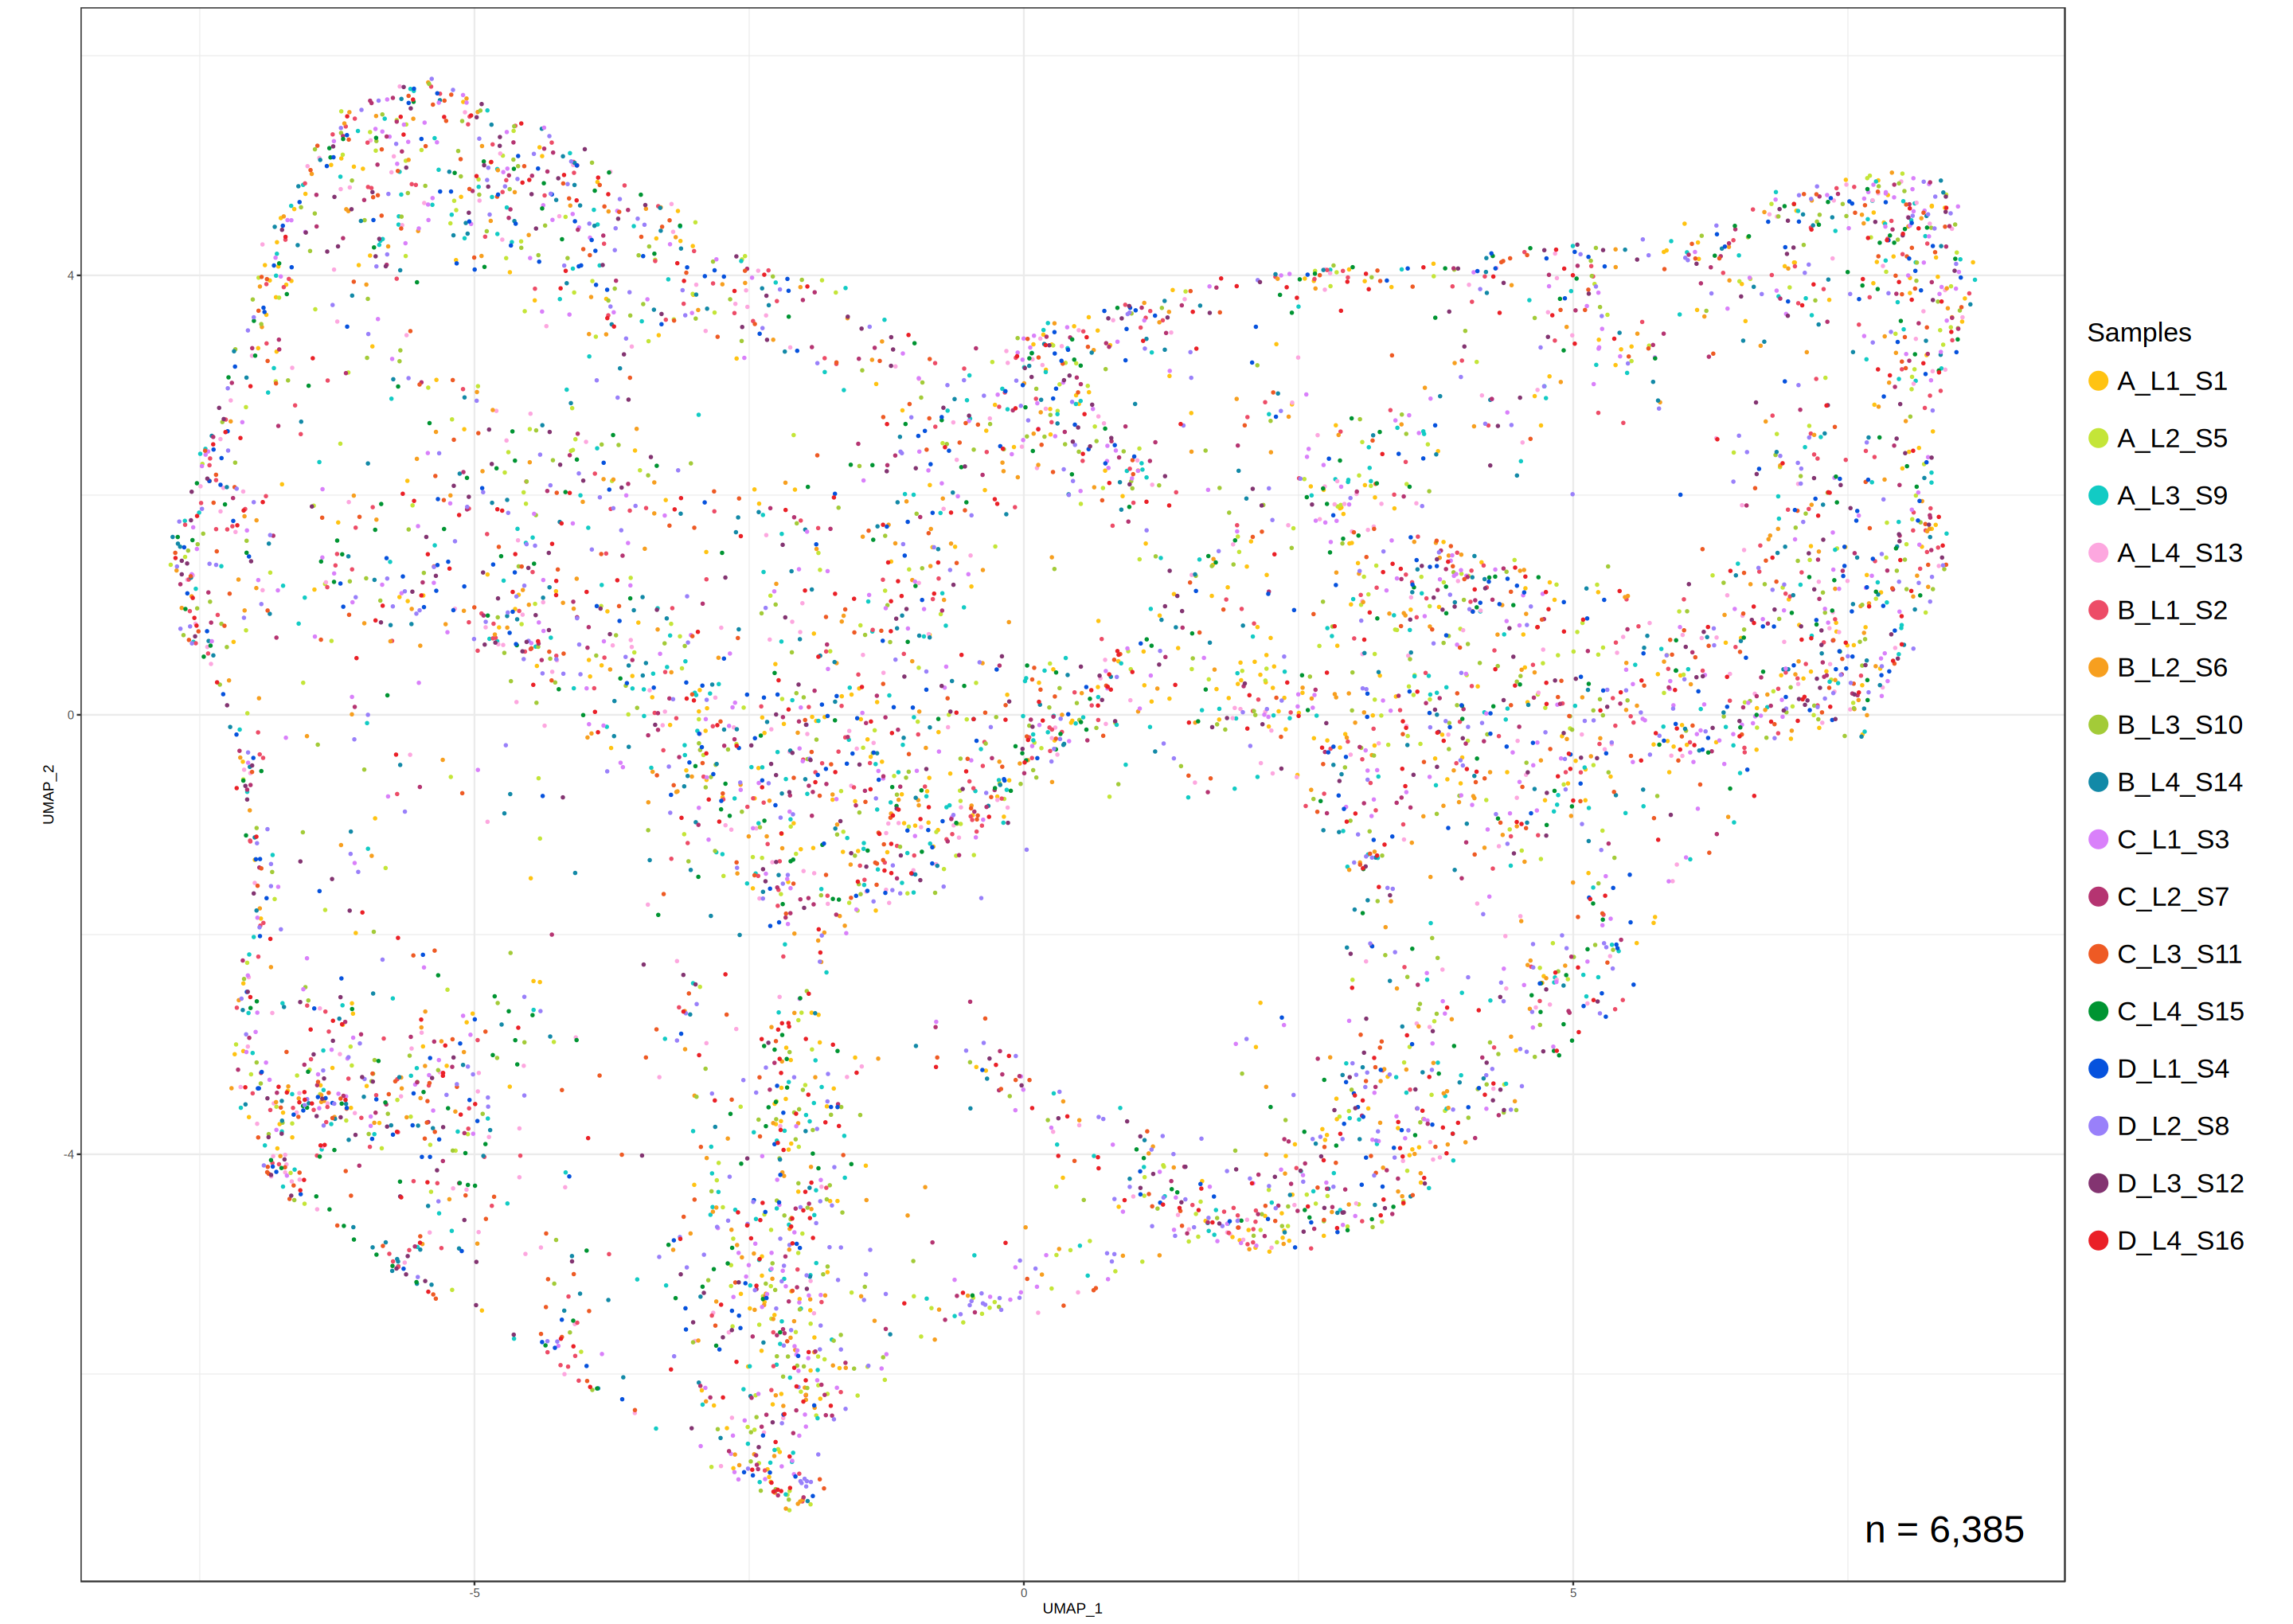

In [ ]:
UMAP_centers_cell_type <- tibble(
    UMAP_1 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_1,
    UMAP_2 = as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)$UMAP_2,
    seurat_clusters = seurat_object_whole_clustering@meta.data$orig.ident
  ) %>%
  group_by(seurat_clusters) %>%
  summarize(x = median(UMAP_1), y = median(UMAP_2))

plot_umap_cluster <- bind_cols(seurat_object_whole_clustering@meta.data, as.data.frame(seurat_object_whole_clustering@reductions$umap@cell.embeddings)) %>%
  ggplot(aes(UMAP_1, UMAP_2, color = orig.ident)) +
  geom_point(size = .5) +
  theme_bw() +
  scale_color_manual(values = custom_colors$discrete) +
  labs(color = 'Samples') +
  guides(colour = guide_legend(override.aes = list(size = 6))) +
  theme(
      legend.position = 'right',
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 20),
      legend.key.height = unit(3,"line")
  ) +
  coord_fixed() +
  annotate(
    geom = 'text', 
    x = Inf, 
    y = -Inf,
    label = paste0('n = ', format(nrow(seurat_object_whole_clustering@meta.data), big.mark = ',', trim = TRUE)),
    vjust = -1.5,
    hjust = 1.25,
    color = 'black',
    size = 10
  )

plot_umap_cluster

In [12]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cluster_3_UMAP_by_samples.svg',
  plot_umap_cluster,
  height = 18,
  width = 20
)

In [26]:
p1 <- seurat_object_whole_clustering@meta.data %>%
  mutate(expression = seurat_object_whole_clustering@assays$SCT@data['Tbr1',]) %>%
  ggplot(aes(x = seurat_clusters, y = expression, fill = seurat_clusters)) +
  geom_violin(draw_quantiles = c(0.5), scale = 'width', trim = TRUE) +
  theme_bw() +
  scale_fill_manual(values = cluster_color_simple) +
  scale_x_discrete() +
  scale_y_continuous(name = 'Log-normalized expression', labels = scales::comma) +
  labs(title = "Tbr1 expression (without noise)") +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    legend.position = 'none'
  )

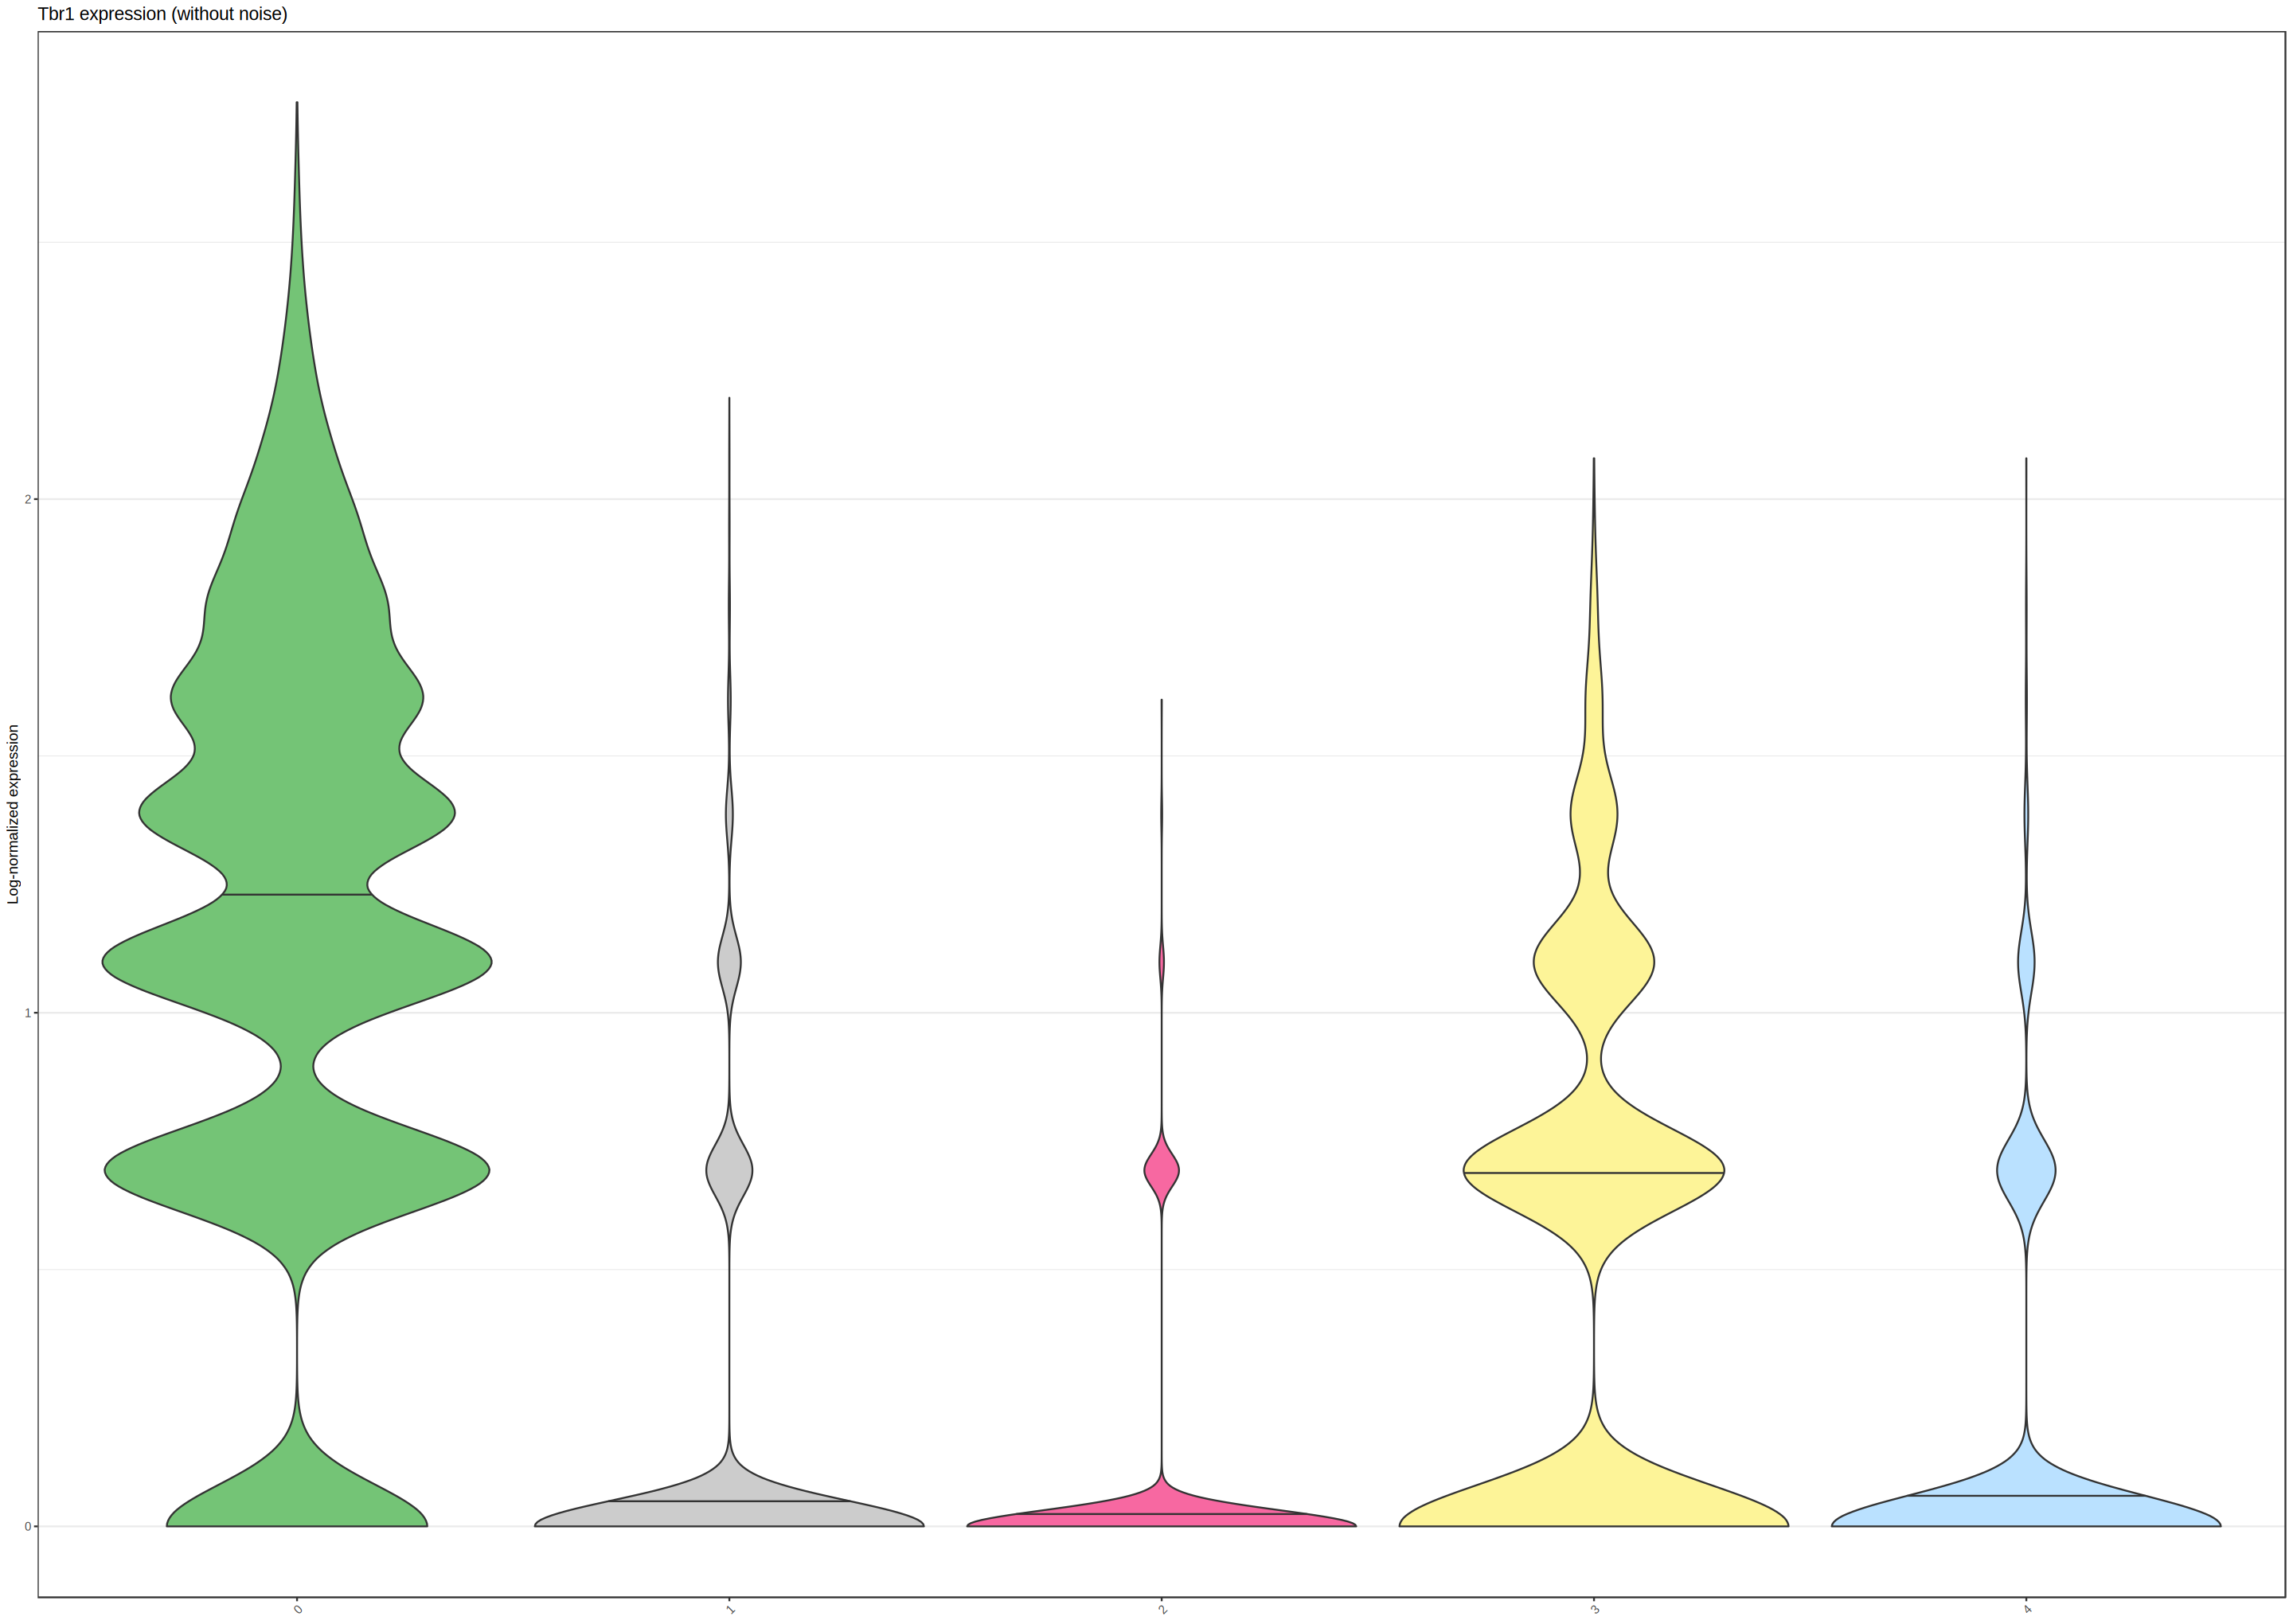

In [27]:
p1

In [41]:
ggsave(
  '/home/adufour/work/plots/epilepsie/tbr1_exp.svg',
  p1,
  height = 18,
  width = 20
)

In [30]:
gene <- "Cabp7"
p2 <- seurat_object_whole_clustering@meta.data %>%
  mutate(expression = seurat_object_whole_clustering@assays$SCT@data[gene,]) %>%
  ggplot(aes(x = seurat_clusters, y = expression, fill = seurat_clusters)) +
  geom_violin(draw_quantiles = c(0.5), scale = 'width', trim = TRUE) +
  theme_bw() +
  scale_fill_manual(values = cluster_color_simple) +
  scale_x_discrete() +
  scale_y_continuous(name = 'Log-normalized expression', labels = scales::comma) +
  labs(title = paste0(gene, " expression (without noise)")) +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    legend.position = 'none'
  )

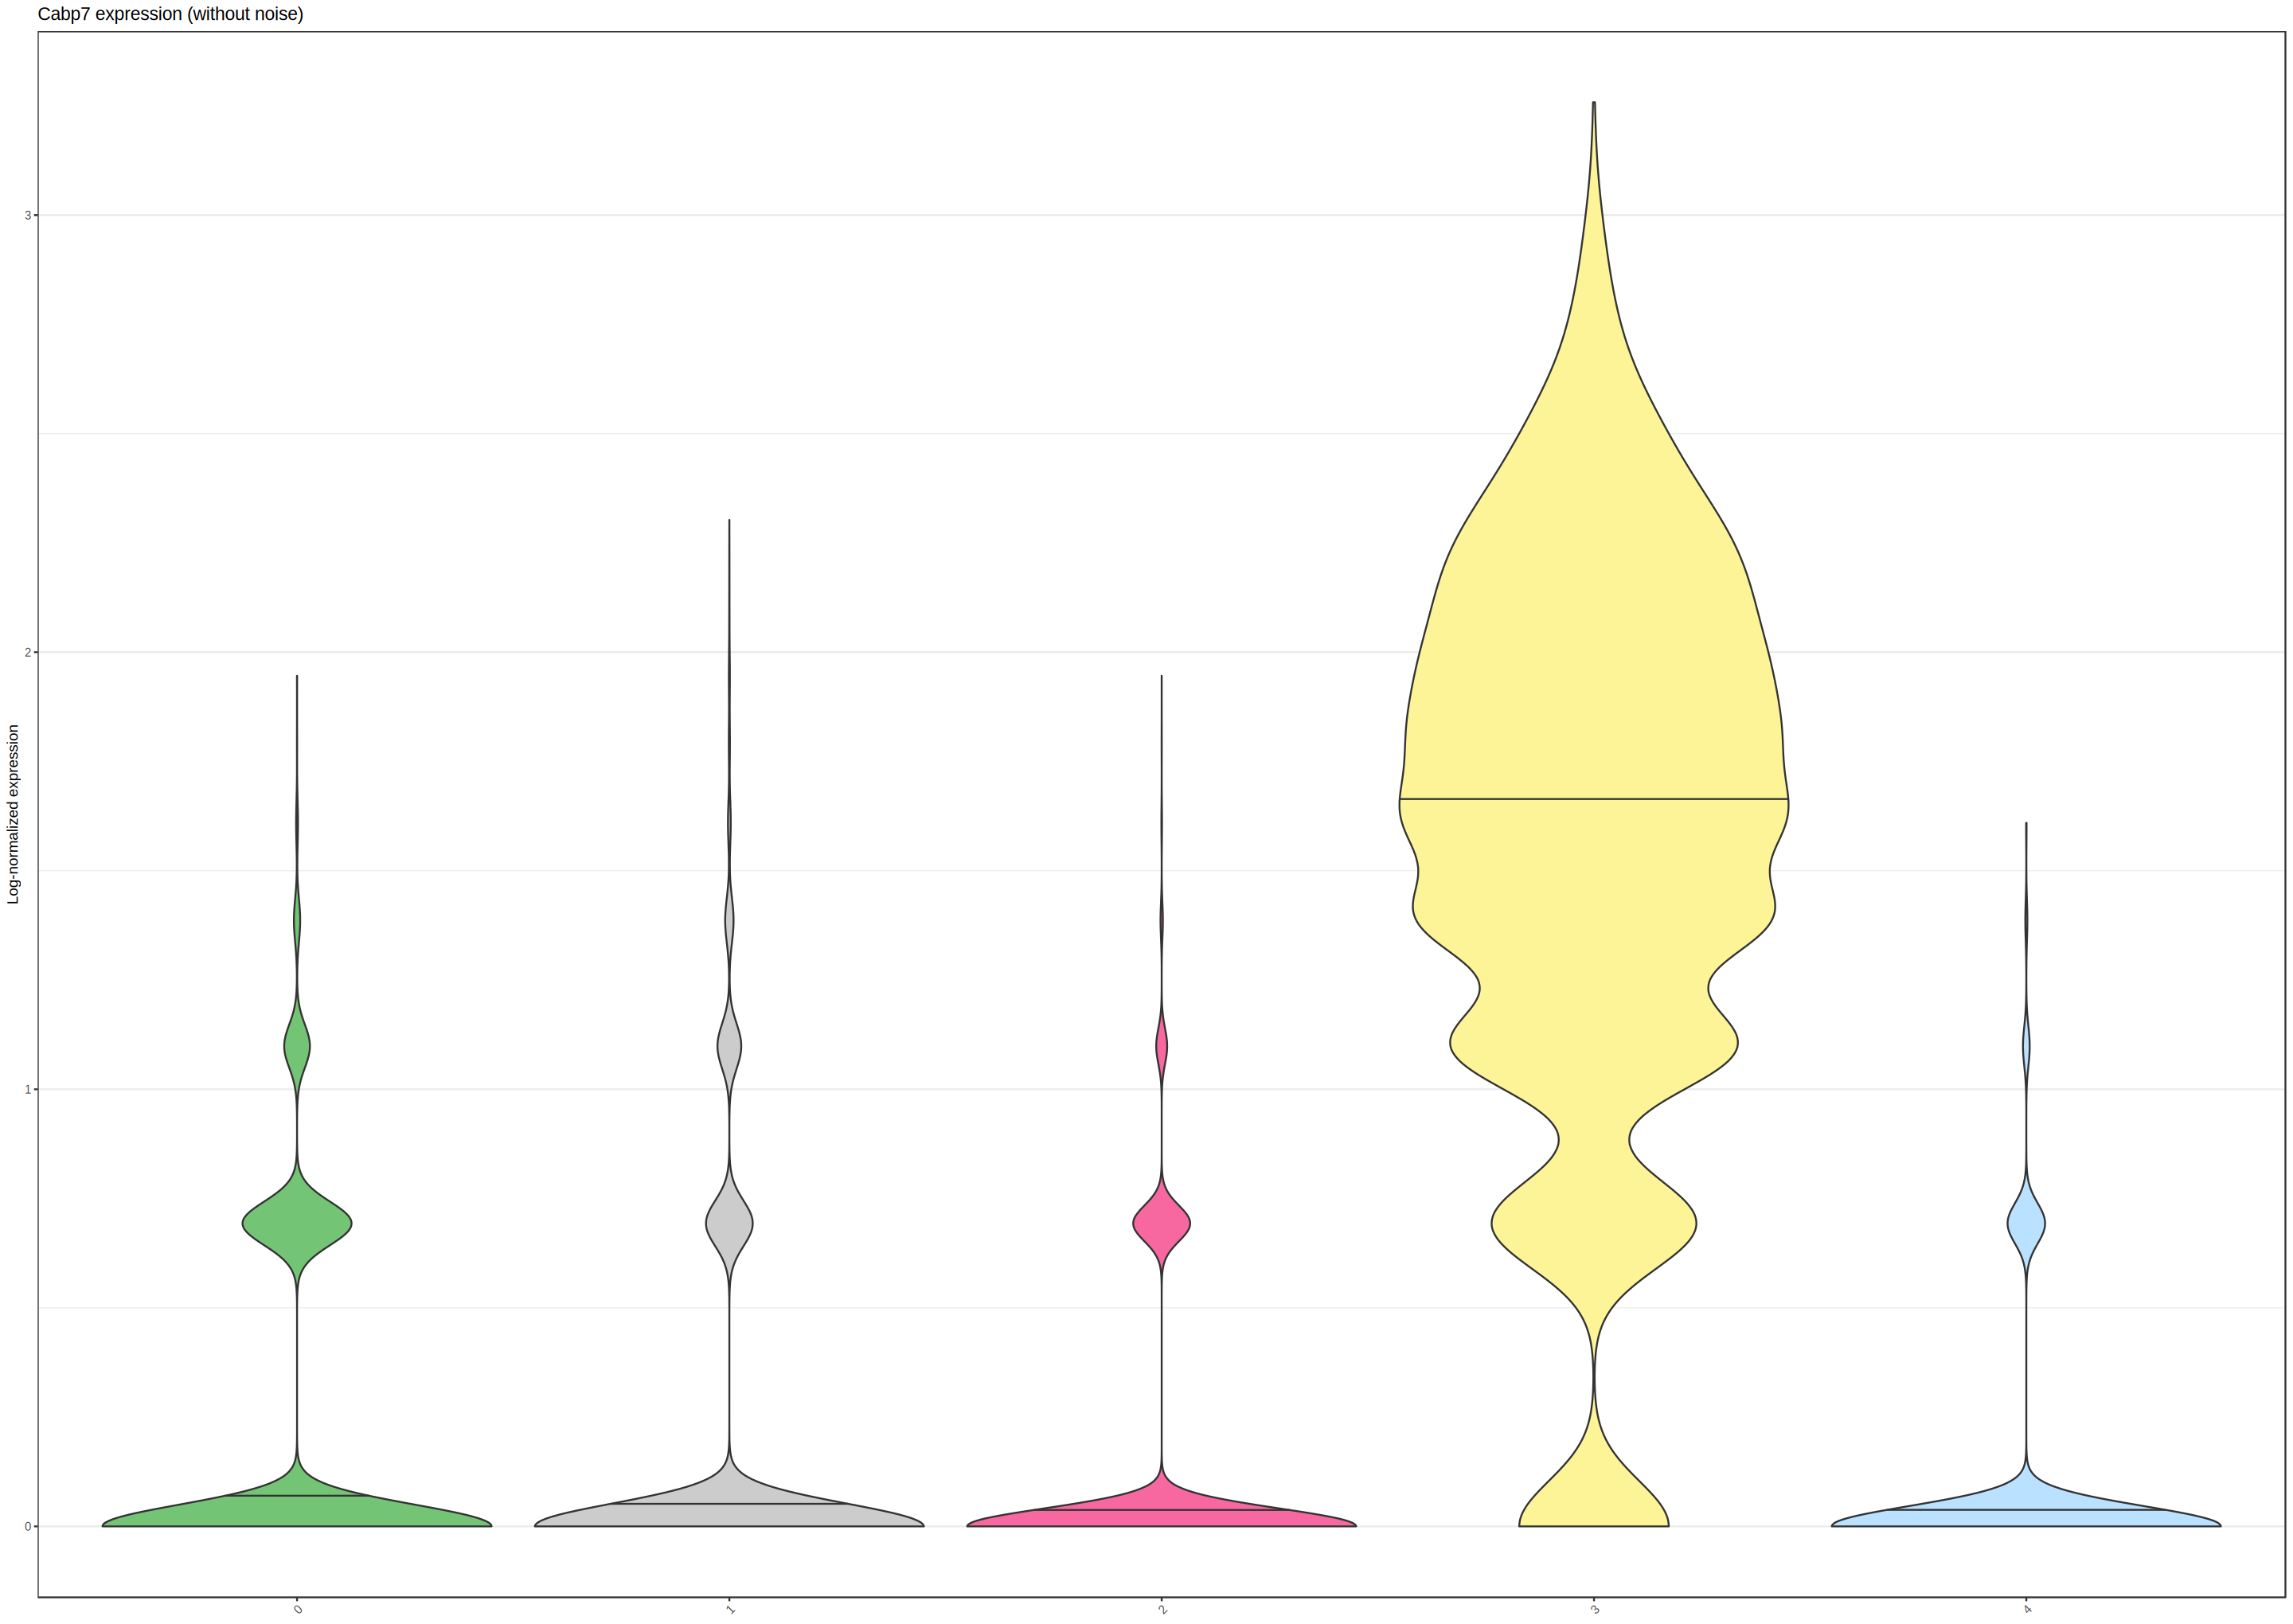

In [31]:
p2

In [42]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cabp7_exp.svg',
  p2,
  height = 18,
  width = 20
)

In [18]:
Idents(seurat_object_whole_clustering) <- "seurat_clusters"
space_plot <- SpatialDimPlot(seurat_object_whole_clustering,
               label = TRUE,
               cols = cluster_color,
               label.size = 6,
               pt.size.factor = 40,
               ncol = 4) +
  theme(legend.position = 'none')

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale

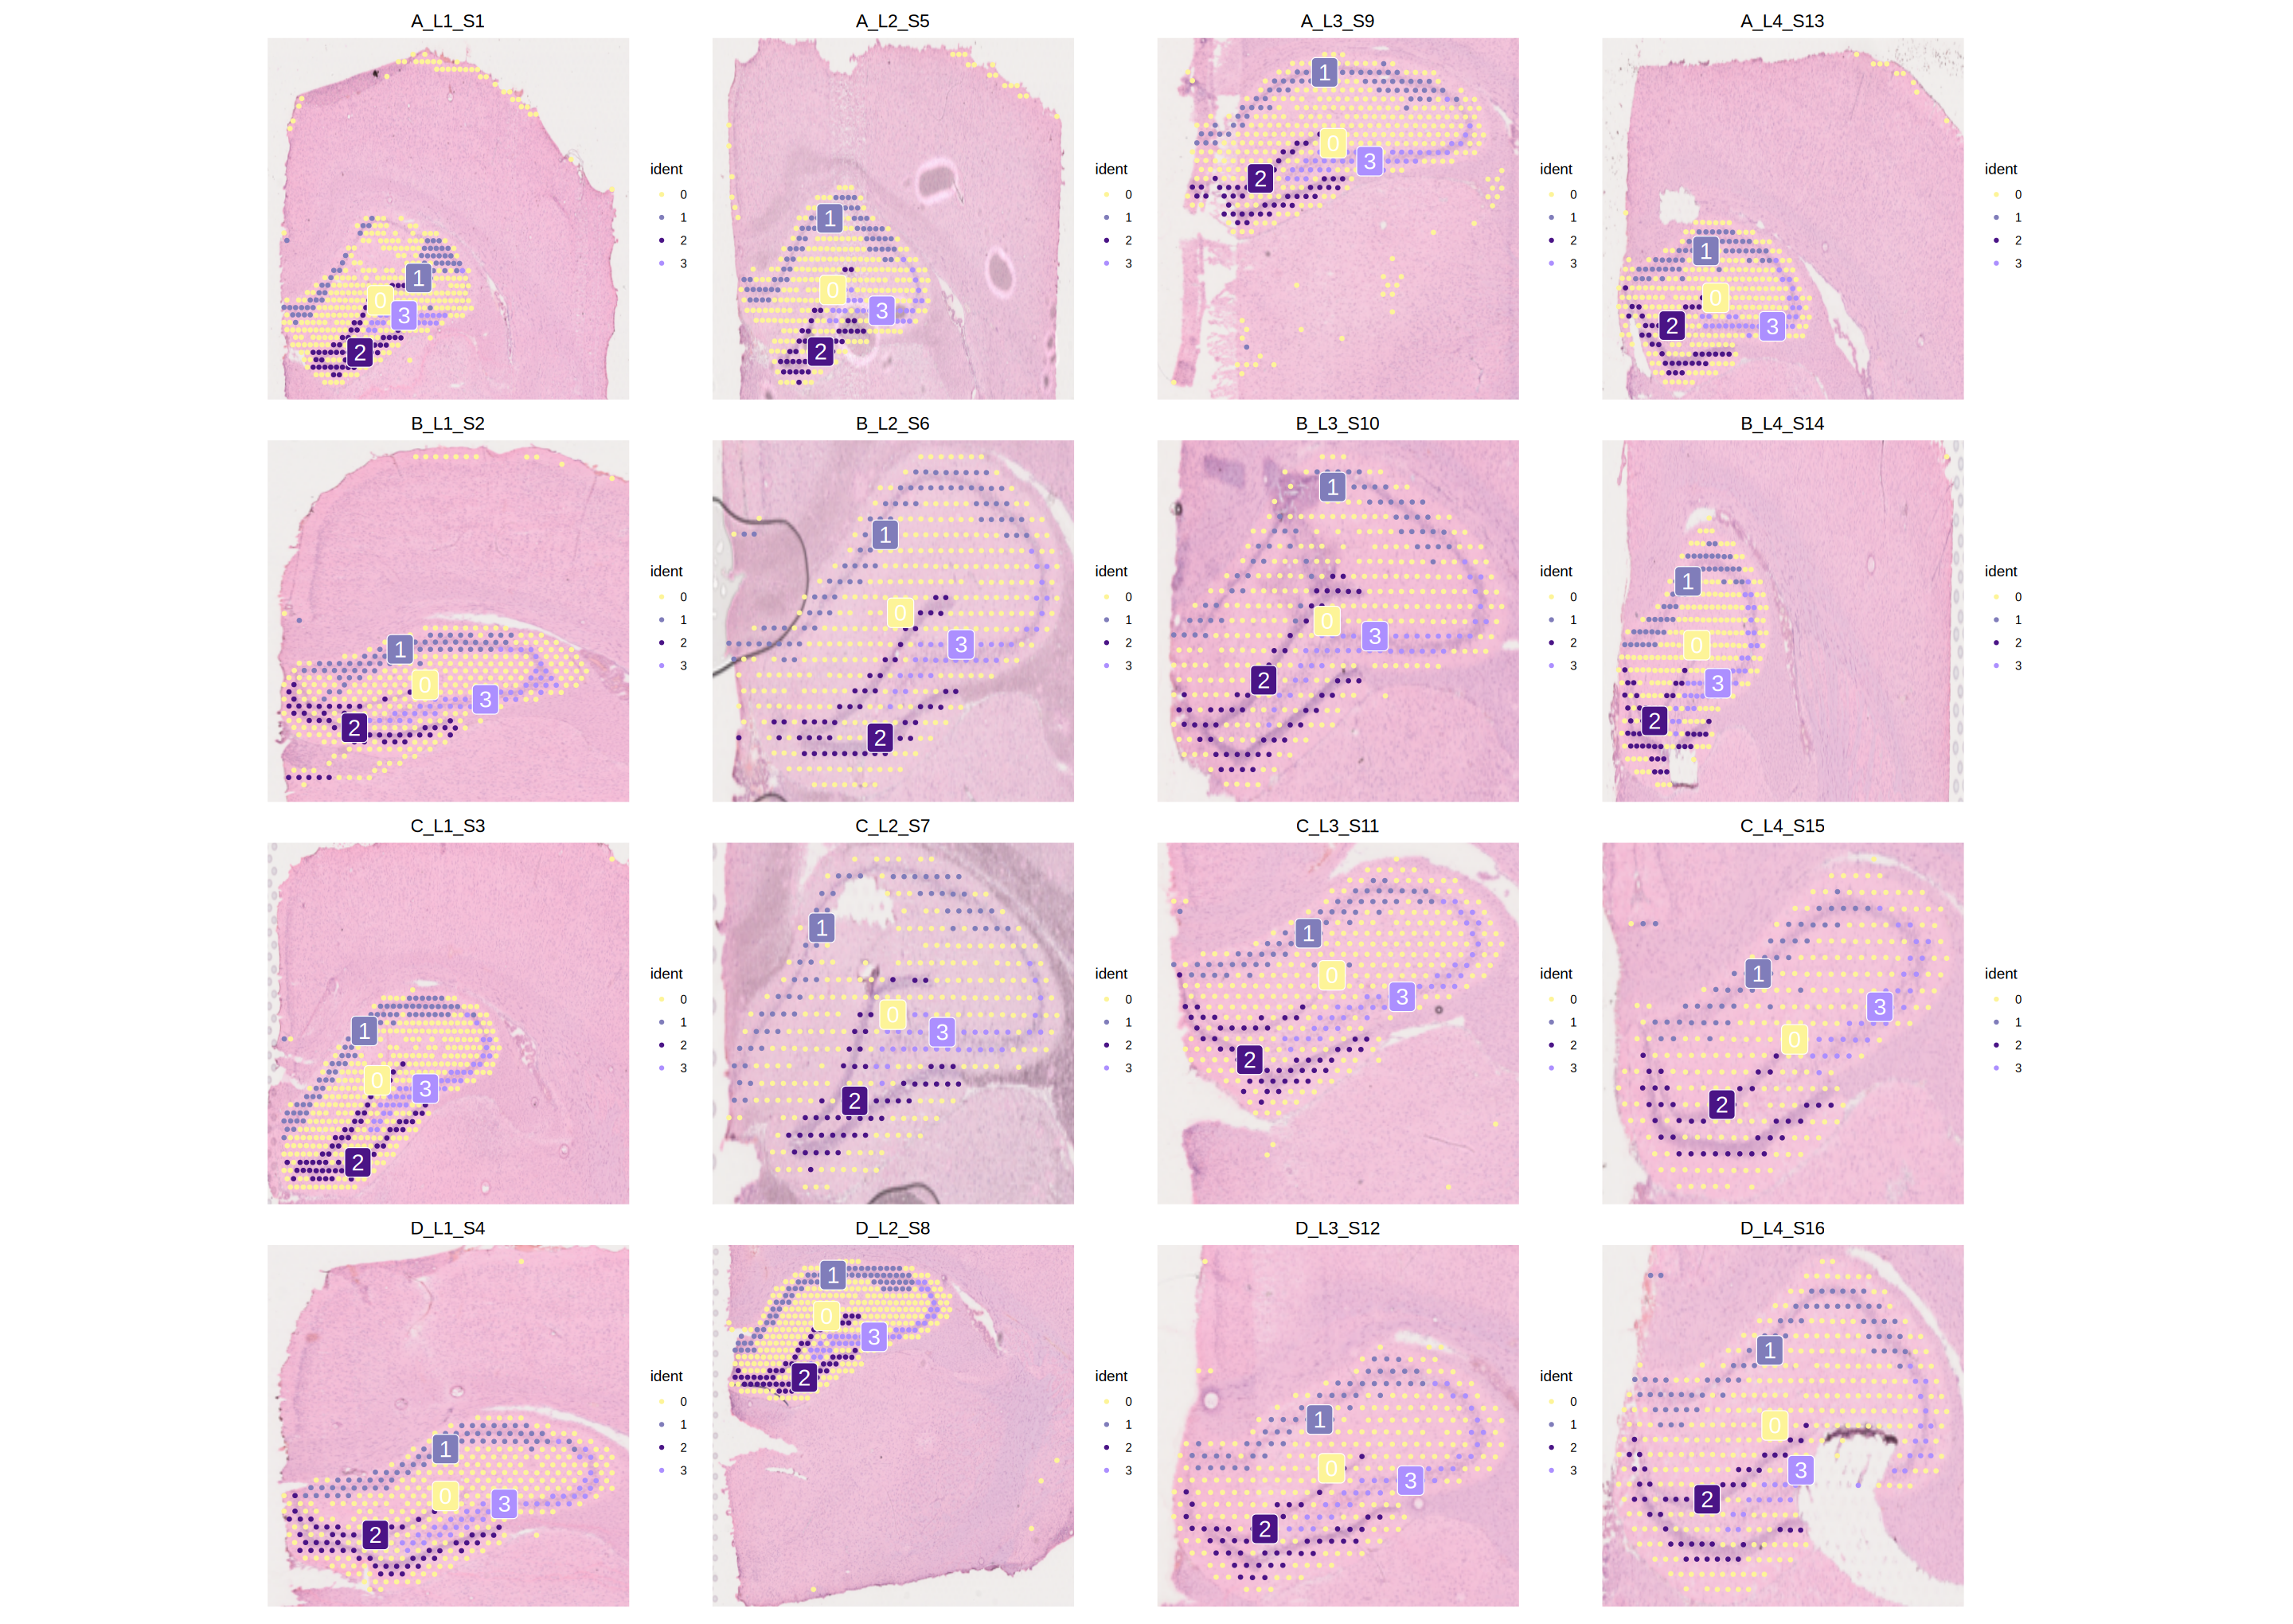

In [19]:
space_plot

In [20]:
ggsave(
  '/home/adufour/work/plots/epilepsie/cluster_3_spatial_clusterinf_simple.svg',
  space_plot,
  height = 18,
  width = 20
)